<a href="https://colab.research.google.com/github/Lucks1747/Desafio/blob/main/C%C3%B3pia_de_FMU_2026_Exemplo_Desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**colab - Disciplina Técnica de Machine Learning - FMU 2025.02**
*  Professor Luciano Tadeu Pereira
* email luciano.tadeu@fmu.br

---

**ATENÇÃO**: Antes de começar, faça uma cópia deste notebook para sua conta do Google Drive. Assim, você poderá editar e testar sem modificar o original.

Para isso, clique em "Arquivo" → "Salvar uma cópia no Drive".

OBS: Para executar este notebook, **não** é necessário um ambiente de execução com GPU.

---

#EXEMPLO DESAFIO PARA NEGÓCIOS


## 🔧 CÉLULA 1: INSTALAÇÃO E IMPORTAÇÃO

```python
# APRENDIZADO DE MÁQUINA SUPERVISIONADO PARA NEGÓCIOS
# Notebook Python para Google Colab

In [ ]:
print("🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!")
print("=" * 60)

# Importar bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas foram importadas com sucesso!")


🚀 Bem-vindos ao Aprendizado de Máquina Supervisionado!
✅ Todas as bibliotecas foram importadas com sucesso!


## 📚 CÉLULA 2: CONCEITO FUNDAMENTAL

In [ ]:
print("\n" + "="*60)
print("📚 CONCEITO FUNDAMENTAL")
print("="*60)

conceito = """
🧠 APRENDIZADO DE MÁQUINA SUPERVISIONADO

Imagine que você é gerente de uma loja e quer ensinar um funcionário novo
a identificar quais clientes têm maior chance de comprar um produto premium.

COMO VOCÊ FARIA?
1️⃣ Mostraria fichas de clientes antigos
2️⃣ Diria: "Este aqui comprou, este não comprou..."
3️⃣ O funcionário aprenderia os padrões
4️⃣ Para novos clientes, ele faria previsões

ISSO É EXATAMENTE o que faz o Aprendizado de Máquina Supervisionado!

📊 EXEMPLOS NO MUNDO DOS NEGÓCIOS:
🏪 VAREJO: Prever se um cliente vai fazer uma compra
💳 BANCOS: Avaliar risco de crédito
📱 MARKETING: Identificar clientes que podem cancelar o serviço
🏥 SEGUROS: Calcular probabilidade de sinistros
📧 E-COMMERCE: Recomendar produtos personalizados
"""

print(conceito)



📚 CONCEITO FUNDAMENTAL

🧠 APRENDIZADO DE MÁQUINA SUPERVISIONADO

Imagine que você é gerente de uma loja e quer ensinar um funcionário novo
a identificar quais clientes têm maior chance de comprar um produto premium.

COMO VOCÊ FARIA?
1️⃣ Mostraria fichas de clientes antigos
2️⃣ Diria: "Este aqui comprou, este não comprou..."
3️⃣ O funcionário aprenderia os padrões
4️⃣ Para novos clientes, ele faria previsões

ISSO É EXATAMENTE o que faz o Aprendizado de Máquina Supervisionado!

📊 EXEMPLOS NO MUNDO DOS NEGÓCIOS:
🏪 VAREJO: Prever se um cliente vai fazer uma compra
💳 BANCOS: Avaliar risco de crédito
📱 MARKETING: Identificar clientes que podem cancelar o serviço
🏥 SEGUROS: Calcular probabilidade de sinistros
📧 E-COMMERCE: Recomendar produtos personalizados



## 📊 CÉLULA 3: CRIANDO BASE DE DADOS

In [ ]:
print("\n" + "="*60)
print("📊 CRIANDO BASE DE DADOS DE CLIENTES")
print("="*60)

# Vamos criar dados realistas de uma empresa

# Gerando 1000 clientes fictícios
n_clientes = 1000

dados_clientes = {
    'idade': np.random.randint(18, 70, n_clientes),
    'renda_mensal': np.random.randint(1500, 15000, n_clientes),
    'tempo_cliente_anos': np.random.randint(0, 10, n_clientes),
    'numero_compras_ano': np.random.randint(0, 20, n_clientes),
    'valor_ultima_compra': np.random.randint(50, 2000, n_clientes),
    'tem_cartao_fidelidade': np.random.choice([0, 1], n_clientes, p=[0.4, 0.6])
}

# Criar variável target (o que queremos prever)
# Lógica: clientes mais velhos, com maior renda, mais tempo como cliente
# e com cartão fidelidade têm maior chance de comprar produto premium
comprou_premium = []

for i in range(n_clientes):
    score = (
        dados_clientes['idade'][i] * 0.01 +
        dados_clientes['renda_mensal'][i] * 0.00008 +
        dados_clientes['tempo_cliente_anos'][i] * 0.1 +
        dados_clientes['numero_compras_ano'][i] * 0.05 +
        dados_clientes['valor_ultima_compra'][i] * 0.0005 +
        dados_clientes['tem_cartao_fidelidade'][i] * 0.3 +
        np.random.normal(0, 0.1)  # Adicionar um pouco de aleatoriedade
    )
    comprou_premium.append(1 if score > 1.2 else 0)

dados_clientes['comprou_premium'] = comprou_premium

# Criar DataFrame
df = pd.DataFrame(dados_clientes)

print(f"✅ Base criada com {len(df)} clientes!")
print(f"📈 {df['comprou_premium'].sum()} clientes compraram produto premium")
print(f"📉 {len(df) - df['comprou_premium'].sum()} clientes NÃO compraram")

# Visualizar os primeiros registros
print("\n🔍 PRIMEIROS 10 CLIENTES:")
print(df.head(10))


📊 CRIANDO BASE DE DADOS DE CLIENTES
✅ Base criada com 1000 clientes!
📈 996 clientes compraram produto premium
📉 4 clientes NÃO compraram

🔍 PRIMEIROS 10 CLIENTES:
   idade  renda_mensal  tempo_cliente_anos  numero_compras_ano  \
0     28         12059                   8                  10   
1     62          9007                   1                  11   
2     49         11651                   4                  11   
3     52         11432                   6                  15   
4     22          3761                   7                   0   
5     55          5825                   2                   3   
6     31          6168                   5                   7   
7     37         12344                   7                  14   
8     34          9221                   2                  13   
9     56          9143                   0                  11   

   valor_ultima_compra  tem_cartao_fidelidade  comprou_premium  
0                  485                      

## 🔍 CÉLULA 4: ANÁLISE EXPLORATÓRIA


🔍 ANÁLISE EXPLORATÓRIA DOS DADOS
📊 ESTATÍSTICAS GERAIS:
            idade  renda_mensal  tempo_cliente_anos  numero_compras_ano  \
count  1000.00000   1000.000000         1000.000000         1000.000000   
mean     43.36800   8170.715000            4.300000            9.449000   
std      15.03518   3857.550497            2.814591            5.752259   
min      18.00000   1518.000000            0.000000            0.000000   
25%      30.00000   4740.000000            2.000000            4.000000   
50%      44.00000   8061.000000            4.000000           10.000000   
75%      56.00000  11545.750000            7.000000           14.000000   
max      69.00000  14997.000000            9.000000           19.000000   

       valor_ultima_compra  tem_cartao_fidelidade  comprou_premium  
count          1000.000000            1000.000000      1000.000000  
mean            998.355000               0.624000         0.996000  
std             569.038781               0.484622         0.

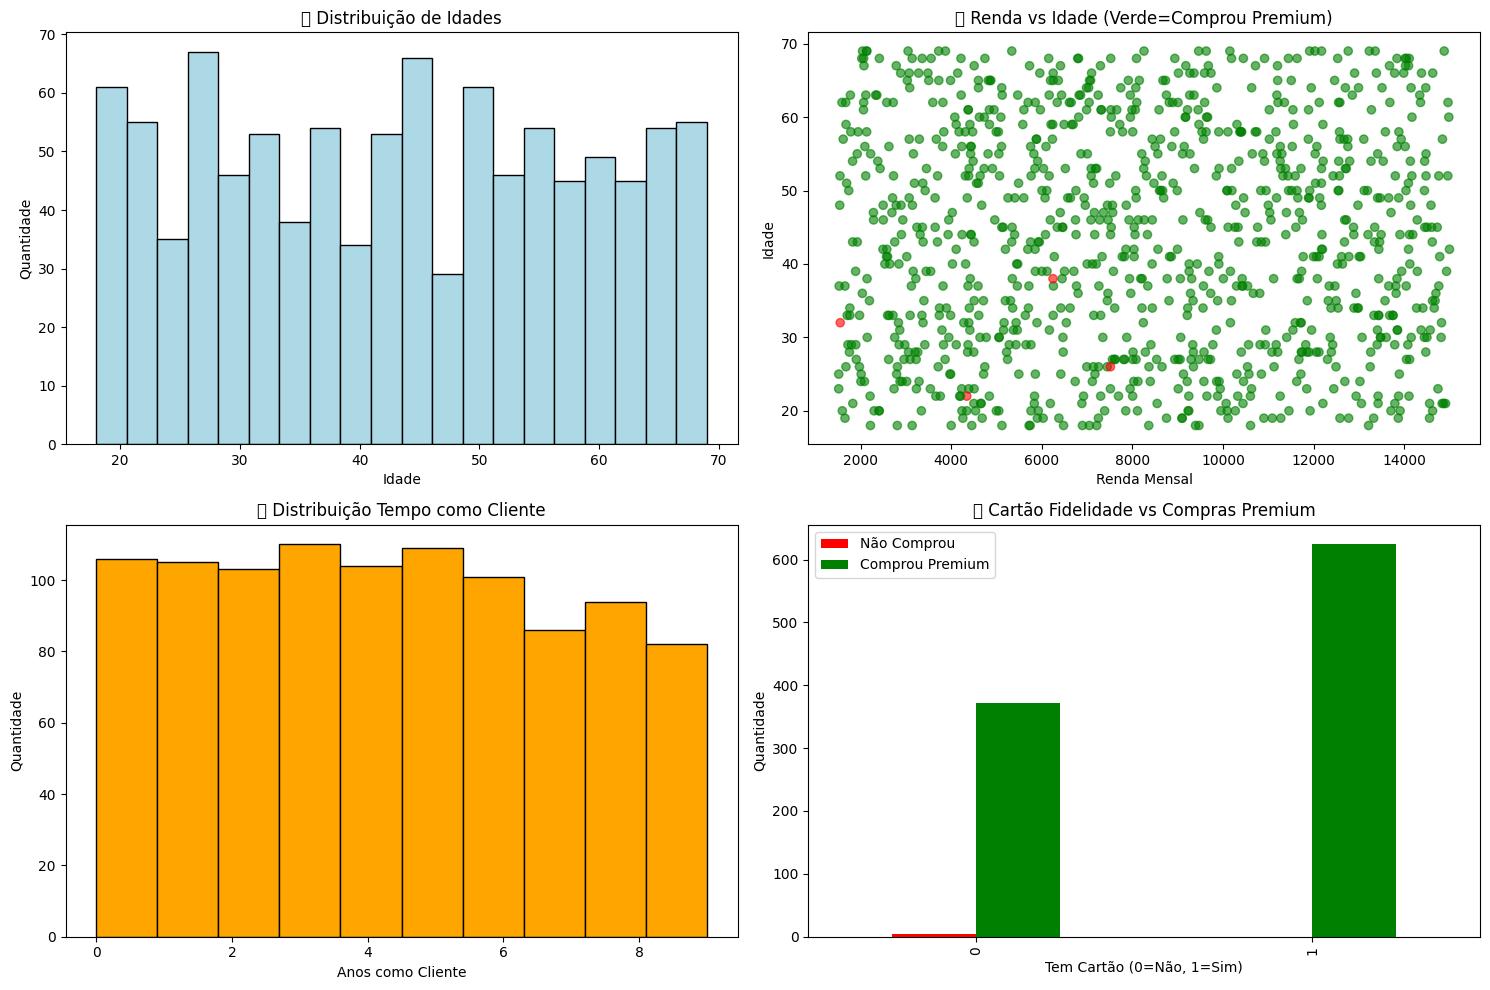


🔗 CORRELAÇÕES COM COMPRA DE PRODUTO PREMIUM:
📈 tem_cartao_fidelidade: 0.082
📈 numero_compras_ano: 0.074
📈 valor_ultima_compra: 0.071
📈 idade: 0.058
📈 renda_mensal: 0.054
📈 tempo_cliente_anos: 0.046


In [ ]:


print("\n" + "="*60)
print("🔍 ANÁLISE EXPLORATÓRIA DOS DADOS")
print("="*60)

# Estatísticas básicas
print("📊 ESTATÍSTICAS GERAIS:")
print(df.describe())

# Visualização das distribuições
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Distribuição de idades
axes[0,0].hist(df['idade'], bins=20, color='lightblue', edgecolor='black')
axes[0,0].set_title('📊 Distribuição de Idades')
axes[0,0].set_xlabel('Idade')
axes[0,0].set_ylabel('Quantidade')

# Gráfico 2: Renda vs Compras Premium
cores = ['red' if x == 0 else 'green' for x in df['comprou_premium']]
axes[0,1].scatter(df['renda_mensal'], df['idade'], c=cores, alpha=0.6)
axes[0,1].set_title('💰 Renda vs Idade (Verde=Comprou Premium)')
axes[0,1].set_xlabel('Renda Mensal')
axes[0,1].set_ylabel('Idade')

# Gráfico 3: Tempo como cliente
axes[1,0].hist(df['tempo_cliente_anos'], bins=10, color='orange', edgecolor='black')
axes[1,0].set_title('⏳ Distribuição Tempo como Cliente')
axes[1,0].set_xlabel('Anos como Cliente')
axes[1,0].set_ylabel('Quantidade')

# Gráfico 4: Cartão fidelidade vs Compras
fidelidade_compras = df.groupby(['tem_cartao_fidelidade', 'comprou_premium']).size().unstack()
fidelidade_compras.plot(kind='bar', ax=axes[1,1], color=['red', 'green'])
axes[1,1].set_title('🏆 Cartão Fidelidade vs Compras Premium')
axes[1,1].set_xlabel('Tem Cartão (0=Não, 1=Sim)')
axes[1,1].set_ylabel('Quantidade')
axes[1,1].legend(['Não Comprou', 'Comprou Premium'])

plt.tight_layout()
plt.show()

# Correlações importantes
print("\n🔗 CORRELAÇÕES COM COMPRA DE PRODUTO PREMIUM:")
correlacoes = df.corr()['comprou_premium'].sort_values(ascending=False)
for variavel, correlacao in correlacoes.items():
    if variavel != 'comprou_premium':
        emoji = "🔥" if abs(correlacao) > 0.3 else "📈" if correlacao > 0 else "📉"
        print(f"{emoji} {variavel}: {correlacao:.3f}")

## 🔧 CÉLULA 5: PREPARANDO DADOS

In [ ]:
print("\n" + "="*60)
print("🔧 PREPARANDO DADOS PARA MACHINE LEARNING")
print("="*60)

# Separar features (características) da variável target (objetivo)
features = ['idade', 'renda_mensal', 'tempo_cliente_anos',
           'numero_compras_ano', 'valor_ultima_compra', 'tem_cartao_fidelidade']

X = df[features]  # Características dos clientes
y = df['comprou_premium']  # O que queremos prever

print("🎯 VARIÁVEIS DO MODELO:")
print(f"Features (X): {features}")
print(f"Target (y): comprou_premium")
print(f"Formato dos dados: {X.shape}")

# Dividir dados em treino e teste (conceito fundamental!)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📚 DADOS DE TREINO: {X_treino.shape[0]} clientes")
print(f"🧪 DADOS DE TESTE: {X_teste.shape[0]} clientes")

explicacao_divisao = """
🤔 POR QUE DIVIDIR OS DADOS?

É como estudar para uma prova:
📚 DADOS DE TREINO = Material que você estuda
🧪 DADOS DE TESTE = Prova real (o modelo nunca viu esses dados)

Se o modelo vai bem na "prova", significa que realmente aprendeu!
"""
print(explicacao_divisao)


🔧 PREPARANDO DADOS PARA MACHINE LEARNING
🎯 VARIÁVEIS DO MODELO:
Features (X): ['idade', 'renda_mensal', 'tempo_cliente_anos', 'numero_compras_ano', 'valor_ultima_compra', 'tem_cartao_fidelidade']
Target (y): comprou_premium
Formato dos dados: (1000, 6)

📚 DADOS DE TREINO: 800 clientes
🧪 DADOS DE TESTE: 200 clientes

🤔 POR QUE DIVIDIR OS DADOS?

É como estudar para uma prova:
📚 DADOS DE TREINO = Material que você estuda
🧪 DADOS DE TESTE = Prova real (o modelo nunca viu esses dados)

Se o modelo vai bem na "prova", significa que realmente aprendeu!



## 🤖 CÉLULA 6: TREINANDO O MODELO


In [ ]:
print("\n" + "="*60)
print("🤖 TREINANDO O MODELO DE MACHINE LEARNING")
print("="*60)

# Vamos usar Random Forest (fácil de entender e interpretar)
print("🌲 Usando algoritmo RANDOM FOREST")
print("💡 Random Forest = Muitas 'árvores de decisão' votando juntas")

modelo = RandomForestClassifier(
    n_estimators=100,  # 100 árvores de decisão
    random_state=42,   # Para resultados reproduzíveis
    max_depth=10       # Profundidade máxima das árvores
)

print("\n🏋️ Treinando o modelo...")
modelo.fit(X_treino, y_treino)
print("✅ Modelo treinado com sucesso!")

# Fazer previsões nos dados de teste
print("\n🔮 Fazendo previsões...")
y_pred = modelo.predict(X_teste)
y_pred_proba = modelo.predict_proba(X_teste)[:, 1]  # Probabilidades

print("✅ Previsões concluídas!")


🤖 TREINANDO O MODELO DE MACHINE LEARNING
🌲 Usando algoritmo RANDOM FOREST
💡 Random Forest = Muitas 'árvores de decisão' votando juntas

🏋️ Treinando o modelo...
✅ Modelo treinado com sucesso!

🔮 Fazendo previsões...
✅ Previsões concluídas!



## 📊 CÉLULA 7: AVALIANDO PERFORMANCE


📊 AVALIANDO A PERFORMANCE DO MODELO
🎯 ACURÁCIA: 99.50%
💡 Isso significa que o modelo acerta 99.50% das previsões!

📋 RELATÓRIO DETALHADO:
                 precision    recall  f1-score   support

    Não Comprou       0.00      0.00      0.00         1
Comprou Premium       0.99      1.00      1.00       199

       accuracy                           0.99       200
      macro avg       0.50      0.50      0.50       200
   weighted avg       0.99      0.99      0.99       200



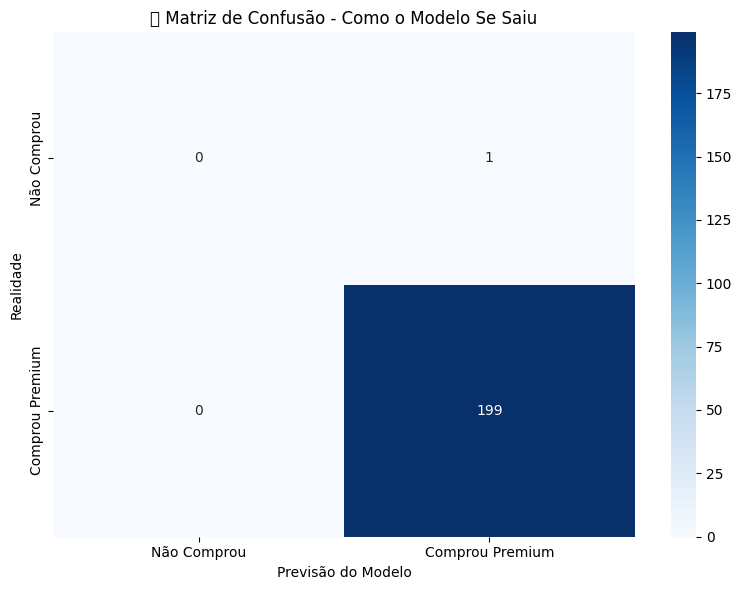


🎯 ENTENDENDO A MATRIZ DE CONFUSÃO:

✅ Acertos:
   - 0 clientes: Modelo previu "Não Comprou" ✓
   - 199 clientes: Modelo previu "Comprou Premium" ✓

❌ Erros:
   - 1 clientes: Previu "Comprou" mas não compraram (Falso Positivo)
   - 0 clientes: Previu "Não Comprou" mas compraram (Falso Negativo)

💰 IMPACTO NO NEGÓCIO:
   - Falso Positivo = Ofereceu desconto desnecessário
   - Falso Negativo = Perdeu oportunidade de venda



In [ ]:
print("\n" + "="*60)
print("📊 AVALIANDO A PERFORMANCE DO MODELO")
print("="*60)

# Acurácia (precisão geral)
acuracia = accuracy_score(y_teste, y_pred)
print(f"🎯 ACURÁCIA: {acuracia:.2%}")
print(f"💡 Isso significa que o modelo acerta {acuracia:.2%} das previsões!")

# Relatório detalhado
print(f"\n📋 RELATÓRIO DETALHADO:")
print(classification_report(y_teste, y_pred,
                          target_names=['Não Comprou', 'Comprou Premium']))

# Matriz de confusão (mais fácil de entender)
cm = confusion_matrix(y_teste, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Não Comprou', 'Comprou Premium'],
           yticklabels=['Não Comprou', 'Comprou Premium'])
plt.title('🎯 Matriz de Confusão - Como o Modelo Se Saiu')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

# Explicação da matriz de confusão
explicacao_matriz = f"""
🎯 ENTENDENDO A MATRIZ DE CONFUSÃO:

✅ Acertos:
   - {cm[0,0]} clientes: Modelo previu "Não Comprou" ✓
   - {cm[1,1]} clientes: Modelo previu "Comprou Premium" ✓

❌ Erros:
   - {cm[0,1]} clientes: Previu "Comprou" mas não compraram (Falso Positivo)
   - {cm[1,0]} clientes: Previu "Não Comprou" mas compraram (Falso Negativo)

💰 IMPACTO NO NEGÓCIO:
   - Falso Positivo = Ofereceu desconto desnecessário
   - Falso Negativo = Perdeu oportunidade de venda
"""
print(explicacao_matriz)


## 🔍 CÉLULA 8: IMPORTÂNCIA DAS VARIÁVEIS


🔍 QUAIS CARACTERÍSTICAS SÃO MAIS IMPORTANTES?
🏆 RANKING DE IMPORTÂNCIA:
renda_mensal.................. 0.362 ████████████████████████████████████
valor_ultima_compra........... 0.227 ██████████████████████
idade......................... 0.140 █████████████
numero_compras_ano............ 0.136 █████████████
tempo_cliente_anos............ 0.090 ████████
tem_cartao_fidelidade......... 0.045 ████


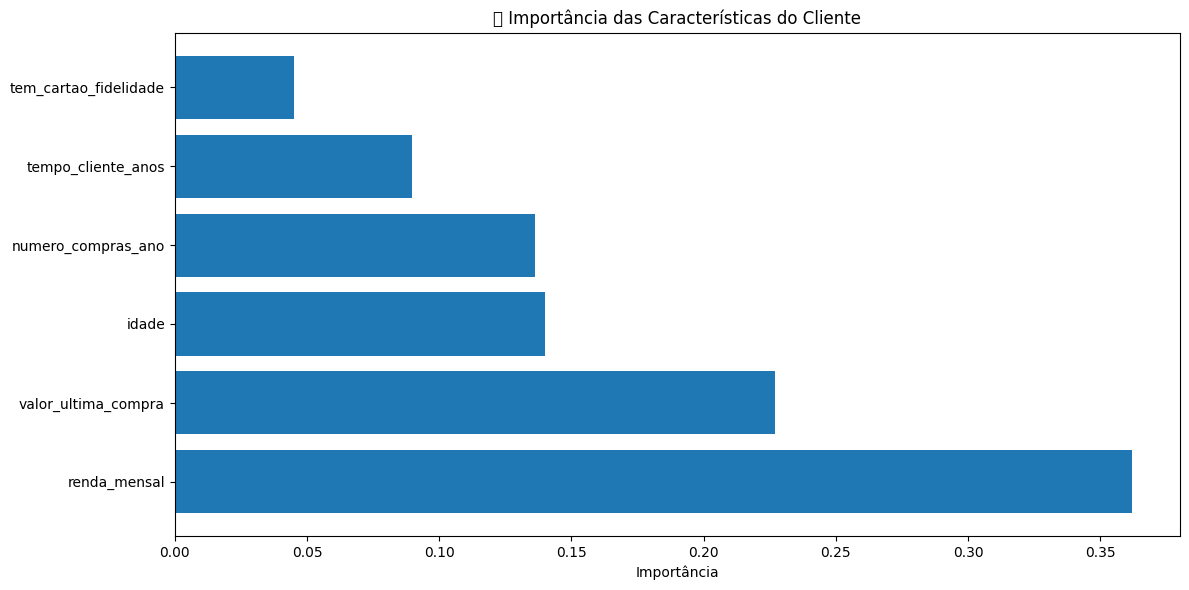


💡 INTERPRETAÇÃO PARA NEGÓCIOS:

As características mais importantes nos dizem:
🔥 Onde focar os esforços de marketing
📊 Que dados coletar dos clientes
💰 Como personalizar ofertas
🎯 Quais segmentos priorizar



In [ ]:
print("\n" + "="*60)
print("🔍 QUAIS CARACTERÍSTICAS SÃO MAIS IMPORTANTES?")
print("="*60)

# Importância das features
importancias = modelo.feature_importances_
features_importancia = pd.DataFrame({
    'Característica': features,
    'Importância': importancias
}).sort_values('Importância', ascending=False)

print("🏆 RANKING DE IMPORTÂNCIA:")
for i, row in features_importancia.iterrows():
    barra = "█" * int(row['Importância'] * 100)
    print(f"{row['Característica']:.<30} {row['Importância']:.3f} {barra}")

# Visualização das importâncias
plt.figure(figsize=(12, 6))
plt.barh(features_importancia['Característica'], features_importancia['Importância'])
plt.title('🎯 Importância das Características do Cliente')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

interpretacao = """
💡 INTERPRETAÇÃO PARA NEGÓCIOS:

As características mais importantes nos dizem:
🔥 Onde focar os esforços de marketing
📊 Que dados coletar dos clientes
💰 Como personalizar ofertas
🎯 Quais segmentos priorizar
"""
print(interpretacao)

## 🔮 CÉLULA 9: FAZENDO PREVISÕES

In [ ]:
print("\n" + "="*60)
print("🔮 FAZENDO PREVISÕES PARA NOVOS CLIENTES")
print("="*60)

def prever_compra_cliente(idade, renda, tempo_cliente, num_compras, valor_ultima, tem_cartao):
    """
    Função para prever se um cliente comprará produto premium
    """
    # Criar array com os dados do cliente
    cliente_dados = np.array([[idade, renda, tempo_cliente, num_compras, valor_ultima, tem_cartao]])

    # Fazer previsão
    probabilidade = modelo.predict_proba(cliente_dados)[0, 1]
    previsao = modelo.predict(cliente_dados)[0]

    return probabilidade, previsao

# Exemplo 1: Cliente Jovem
print("👨 CLIENTE 1 - JOVEM EXECUTIVO:")
cliente1_prob, cliente1_pred = prever_compra_cliente(
    idade=28, renda=4500, tempo_cliente=2, num_compras=5, valor_ultima=300, tem_cartao=1
)
print(f"   Probabilidade: {cliente1_prob:.1%}")
print(f"   Previsão: {'🟢 COMPRARÁ' if cliente1_pred else '🔴 NÃO COMPRARÁ'}")

# Exemplo 2: Cliente Sênior
print("\n👴 CLIENTE 2 - EXECUTIVO SÊNIOR:")
cliente2_prob, cliente2_pred = prever_compra_cliente(
    idade=45, renda=8000, tempo_cliente=6, num_compras=15, valor_ultima=800, tem_cartao=1
)
print(f"   Probabilidade: {cliente2_prob:.1%}")
print(f"   Previsão: {'🟢 COMPRARÁ' if cliente2_pred else '🔴 NÃO COMPRARÁ'}")

# Exemplo 3: Cliente Iniciante
print("\n👨‍🎓 CLIENTE 3 - RECÉM-FORMADO:")
cliente3_prob, cliente3_pred = prever_compra_cliente(
    idade=23, renda=2500, tempo_cliente=1, num_compras=2, valor_ultima=150, tem_cartao=0
)
print(f"   Probabilidade: {cliente3_prob:.1%}")
print(f"   Previsão: {'🟢 COMPRARÁ' if cliente3_pred else '🔴 NÃO COMPRARÁ'}")


🔮 FAZENDO PREVISÕES PARA NOVOS CLIENTES
👨 CLIENTE 1 - JOVEM EXECUTIVO:
   Probabilidade: 100.0%
   Previsão: 🟢 COMPRARÁ

👴 CLIENTE 2 - EXECUTIVO SÊNIOR:
   Probabilidade: 100.0%
   Previsão: 🟢 COMPRARÁ

👨‍🎓 CLIENTE 3 - RECÉM-FORMADO:
   Probabilidade: 83.0%
   Previsão: 🟢 COMPRARÁ


## 🎮 CÉLULA 10: SIMULADOR INTERATIVO

In [ ]:
print("\n" + "="*60)
print("🎮 SIMULADOR INTERATIVO")
print("="*60)

def simulador_cliente():
    """
    Simulador interativo para testar diferentes perfis de cliente
    """
    print("🎯 Digite os dados do cliente para ver a previsão:")

    try:
        idade = int(input("👤 Idade (18-70): "))
        renda = int(input("💰 Renda mensal (R$ 1500-15000): "))
        tempo = int(input("⏳ Tempo como cliente (0-10 anos): "))
        compras = int(input("🛒 Compras no último ano (0-20): "))
        valor = int(input("💳 Valor da última compra (R$ 50-2000): "))
        cartao = int(input("🏆 Tem cartão fidelidade? (0=Não, 1=Sim): "))

        prob, pred = prever_compra_cliente(idade, renda, tempo, compras, valor, cartao)

        print(f"\n{'='*50}")
        print(f"🎯 RESULTADO DA PREVISÃO:")
        print(f"📊 Probabilidade: {prob:.1%}")
        print(f"🔮 Previsão: {'🟢 COMPRARÁ PREMIUM' if pred else '🔴 NÃO COMPRARÁ'}")

        # Recomendações de negócio
        if prob > 0.7:
            print(f"💡 AÇÃO: Cliente de alto potencial! Ofereça desconto premium.")
        elif prob > 0.4:
            print(f"💡 AÇÃO: Cliente intermediário. Envie email marketing personalizado.")
        else:
            print(f"💡 AÇÃO: Cliente de baixo potencial. Foque em produtos básicos.")

    except ValueError:
        print("❌ Por favor, digite apenas números!")

# Execute esta célula e depois chame a função:
simulador_cliente()

print("✅ Função simulador_cliente() criada!")
print("💡 Para usar o simulador, execute: simulador_cliente()")


🎮 SIMULADOR INTERATIVO
🎯 Digite os dados do cliente para ver a previsão:
👤 Idade (18-70): 25
💰 Renda mensal (R$ 1500-15000): 3500
⏳ Tempo como cliente (0-10 anos): 6
🛒 Compras no último ano (0-20): 10
💳 Valor da última compra (R$ 50-2000): 100
🏆 Tem cartão fidelidade? (0=Não, 1=Sim): 1

🎯 RESULTADO DA PREVISÃO:
📊 Probabilidade: 96.0%
🔮 Previsão: 🟢 COMPRARÁ PREMIUM
💡 AÇÃO: Cliente de alto potencial! Ofereça desconto premium.
✅ Função simulador_cliente() criada!
💡 Para usar o simulador, execute: simulador_cliente()


## 🌍 CÉLULA 11: APLICAÇÕES NO MUNDO REAL

In [ ]:
print("\n" + "="*60)
print("🌍 APLICAÇÕES NO MUNDO REAL DOS NEGÓCIOS")
print("="*60)

aplicacoes = """
🏪 VAREJO E E-COMMERCE:
   ✅ Prever abandono de carrinho
   ✅ Recomendar produtos
   ✅ Personalizar preços e ofertas
   ✅ Otimizar campanhas de email marketing

🏦 SETOR FINANCEIRO:
   ✅ Análise de risco de crédito
   ✅ Detecção de fraudes
   ✅ Previsão de inadimplência
   ✅ Segmentação de clientes

📱 MARKETING DIGITAL:
   ✅ Identificar clientes em risco de churn
   ✅ Otimizar gastos em publicidade
   ✅ Personalizar conteúdo
   ✅ Prever lifetime value

🏥 SEGUROS E SAÚDE:
   ✅ Precificação de apólices
   ✅ Avaliação de riscos
   ✅ Detecção de fraudes
   ✅ Previsão de sinistros

📊 EXEMPLOS DE ROI:
   💰 Netflix: 1 bilhão de dólares em economia com sistema de recomendação
   💰 Amazon: 35% das vendas vêm de recomendações ML
   💰 Bancos: Redução de 50% em fraudes com ML
   💰 Marketing: Aumento de 20% na conversão com personalização
"""

print(aplicacoes)


🌍 APLICAÇÕES NO MUNDO REAL DOS NEGÓCIOS

🏪 VAREJO E E-COMMERCE:
   ✅ Prever abandono de carrinho
   ✅ Recomendar produtos
   ✅ Personalizar preços e ofertas
   ✅ Otimizar campanhas de email marketing

🏦 SETOR FINANCEIRO:
   ✅ Análise de risco de crédito
   ✅ Detecção de fraudes
   ✅ Previsão de inadimplência
   ✅ Segmentação de clientes

📱 MARKETING DIGITAL:
   ✅ Identificar clientes em risco de churn
   ✅ Otimizar gastos em publicidade
   ✅ Personalizar conteúdo
   ✅ Prever lifetime value

🏥 SEGUROS E SAÚDE:
   ✅ Precificação de apólices
   ✅ Avaliação de riscos
   ✅ Detecção de fraudes
   ✅ Previsão de sinistros

📊 EXEMPLOS DE ROI:
   💰 Netflix: 1 bilhão de dólares em economia com sistema de recomendação
   💰 Amazon: 35% das vendas vêm de recomendações ML
   💰 Bancos: Redução de 50% em fraudes com ML
   💰 Marketing: Aumento de 20% na conversão com personalização



## 🚀 CÉLULA 12: PRÓXIMOS PASSOS E CONCLUSÃO

In [ ]:
print("\n" + "="*60)
print("🚀 PRÓXIMOS PASSOS PARA IMPLEMENTAR ML NO SEU NEGÓCIO")
print("="*60)

proximos_passos = """
1️⃣ IDENTIFIQUE O PROBLEMA:
   - Que decisão você quer automatizar?
   - Que previsão seria valiosa para seu negócio?

2️⃣ COLETE DADOS:
   - Dados históricos de clientes
   - Dados de transações
   - Dados de comportamento online

3️⃣ COMECE SIMPLES:
   - Use ferramentas como Google Analytics Intelligence
   - Experimente plataformas no-code como H2O.ai
   - Considere consultorias especializadas

4️⃣ MEÇA RESULTADOS:
   - Defina KPIs claros
   - Compare com métodos tradicionais
   - Ajuste continuamente

5️⃣ EXPANDA GRADUALMENTE:
   - Comece com um caso de uso
   - Aprenda com os resultados
   - Escale para outras áreas
"""

print(proximos_passos)

print("\n" + "="*60)
print("🎓 CONCLUSÃO")
print("="*60)

conclusao = """
🎯 VOCÊ APRENDEU:
✅ O que é Aprendizado de Máquina Supervisionado
✅ Como preparar dados para ML
✅ Como treinar e avaliar um modelo
✅ Como interpretar resultados
✅ Como aplicar ML nos negócios

💡 LEMBRE-SE:
- ML não é mágica, é uma ferramenta poderosa
- Qualidade dos dados = Qualidade dos resultados
- Comece simples, evolua gradualmente
- Sempre valide resultados com especialistas do negócio

🚀 AGORA É SUA VEZ:
   Identifique um problema no seu trabalho ou empresa
   que poderia se beneficiar de ML e comece pequeno!
"""

print(conclusao)

print("\n🎉 Parabéns! Você concluiu o curso de ML Supervisionado para Negócios!")
print("="*60)

## 🎯 RESUMO DO NOTEBOOK:

**12 células de código** que cobrem:
- ✅ Conceitos fundamentais sem matemática
- ✅ Criação de dados realistas de clientes
- ✅ Análise exploratória com gráficos
- ✅ Treinamento do modelo Random Forest
- ✅ Avaliação de performance
- ✅ Interpretação de resultados
- ✅ Previsões para novos clientes
- ✅ Simulador interativo
- ✅ Aplicações práticas nos negócios